
# Section 6 — repository-native experiment notebook

Run this notebook from the root of:

```text
aayushmanda/Trace
```

This version deliberately reuses the repository's existing training stack wherever the experiment is about the **actual Transformer**:

```python
from src.registry import TASKS
from src.utils import (
    build_model,          # returns (base_model, compiled_model)
    build_optimizer,
    build_train_loader,
    set_seed,
    cleanup,
)
from compare_supervision import (
    SupervisionDataset,
    evaluate,
    generate_unique,
)
from mechanism_diagnostics import build_teacher_queries
```

On CUDA, `src.utils.build_model(..., use_compile=True)` uses the repository's own

```python
torch.compile(base_model, mode="reduce-overhead")
```

path. Training runs through the compiled model; checkpointing, generation, and mechanistic inspection use `base_model`, which shares the same parameters.

There are only two places where custom models are intentional:

- **6.1 / 6.2A:** the theorem's explicit transition-matrix executor is not `src.model.GPTModel`, so it must be implemented as transition matrices.
- **6.4:** Theorem 6 is stated for a **one-block, no-LayerNorm** architecture, whereas `src.model.GPTModel` is the empirical pre-LN Transformer. Reusing `GPTModel` there would make the theorem check architecturally wrong.

No experiment cells in this notebook have been executed.



## 6.1 — Escape time versus initialization scale and depth

The main run uses row-stochastic tangent flow and **measures** the marginal component rather than forcing it away. A second optional `conditional` run enforces `gamma≈0` and tests the stronger branch of Theorem 4.

The practical `full` profile stays inside the local neighborhood and is intended to produce estimable slopes. The `paper` profile reproduces the extreme epsilon grid currently written in the draft; at `D=6` it may be heavily censored within any reasonable budget.

**Numerical boundary handling.** The matrix update uses fixed-size Euclidean projected gradient descent on each row simplex. The notebook records when the projection becomes active. For the cleanest theorem comparison, also run `S61.escape_metric="phi"`; this records the first persistent crossing of $\varphi(t)\ge2\varphi(0)$, the boundary appearing directly in Theorem 4. The gate-recovery crossing remains available to match the current draft protocol.


In [1]:
"""
validate_section6_1_escape.py

Paper Section 6.1: escape time versus initialization scale and depth.

This is a theorem-aligned transition-matrix experiment that uses the actual
4-bit reversible Boolean gate semantics from aayushmanda/Trace:
    src.boolean_circuit_tasks._apply_gate

Key design choices:
  * K=16 states and all 52 gate strings used by the repo grammar.
  * The same random initialization direction and the same finite population
    are reused across eps values for a given (depth, seed).
  * P_g(0) = (1-eps) U + eps R_g with R_g a permutation matrix, so
        phi(0) = eps   and   gamma(0) = 0
    up to floating-point precision.
  * Optimization is plain gradient descent directly in transition-matrix
    coordinates, matching Theorem 4 more closely than Adam/softmax logits.
  * The finite population crosses every sampled gate sequence with all 16
    initial states. Therefore the terminal target is exactly uniform for each
    sampled sequence, not merely approximately uniform.
  * Gate marginals at each depth position are exactly balanced according to
    either a uniform distribution over 52 strings or the repo's family-uniform
    sampler distribution.
  * We track phi, gamma, min(P), Assumption-1 ratio gamma/phi^(D-1), gate
    recovery, censoring, and backtracking.
  * Escape is persistent recovery above chance + 5 percentage points.

Run from the Trace repository root.

Examples
--------
Pilot:
    python validate_section6_1_escape.py --profile pilot --seeds 2001 --device cuda

Final five-seed run:
    python validate_section6_1_escape.py --profile full \
        --seeds 2001 2002 2003 2004 2005 --device cuda

Stronger gamma=0 branch:
    python validate_section6_1_escape.py --profile full --flow conditional \
        --seeds 2001 2002 2003 2004 2005 --device cuda

Exact eps grid currently written in the draft (likely heavily censored at D=6):
    python validate_section6_1_escape.py --profile paper \
        --seeds 2001 2002 2003 2004 2005 --device cuda
"""

import argparse
import csv
import itertools
import json
import math
import os
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch

from src.boolean_circuit_tasks import _apply_gate, _bits


K = 16
N_BITS = 4
CHANCE = 100.0 / K

PROFILES = {
    # Fast sanity check before spending compute.
    "pilot": {
        3: [0.15, 0.10, 0.07],
        4: [0.20, 0.14, 0.10],
        6: [0.30, 0.24, 0.19],
    },
    # Practical grid kept inside Theorem 3's phi <= 1/2 neighborhood.
    "full": {
        3: [0.15, 0.10, 0.07, 0.05, 0.035],
        4: [0.20, 0.14, 0.10, 0.07, 0.05],
        6: [0.30, 0.24, 0.19, 0.15, 0.12, 0.10],
    },
    # Grid currently written in the draft. Small-eps D=6 points can be
    # legitimately censored because the stronger branch scales as eps^-(D-2).
    "paper": {
        3: [1e-1, 10 ** -1.5, 1e-2, 10 ** -2.5, 1e-3],
        4: [1e-1, 10 ** -1.5, 1e-2, 10 ** -2.5, 1e-3],
        6: [1e-1, 10 ** -1.5, 1e-2, 10 ** -2.5, 1e-3],
    },
}

DEFAULT_MAX_STEPS = {
    "pilot": {3: 5_000, 4: 12_000, 6: 25_000},
    "full":  {3: 20_000, 4: 50_000, 6: 100_000},
    "paper": {3: 100_000, 4: 100_000, 6: 100_000},
}


def enumerate_repo_gate_strings():
    """All 52 strings admitted by the repo's _sample_gate grammar."""
    gates = []
    gates += [f"x{i}" for i in range(N_BITS)]
    gates += [f"c{i}{j}" for i in range(N_BITS) for j in range(N_BITS) if i != j]
    gates += [f"s{i}{j}" for i in range(N_BITS) for j in range(N_BITS) if i != j]
    gates += [
        f"t{i}{j}{k}"
        for i in range(N_BITS)
        for j in range(N_BITS)
        for k in range(N_BITS)
        if len({i, j, k}) == 3
    ]
    assert len(gates) == 52, len(gates)
    return gates


GATES = enumerate_repo_gate_strings()
M = len(GATES)


def bits_to_int(bits):
    return int("".join(str(int(b)) for b in bits), 2)


def build_true_gate_table(device):
    """true_gates[g, s] = g(s), using the repository implementation."""
    table = torch.empty(M, K, dtype=torch.long)
    for gi, gate in enumerate(GATES):
        outputs = []
        for s in range(K):
            outputs.append(bits_to_int(_apply_gate(_bits(s), gate)))
        # Every legal gate must be a permutation of the 16 states.
        assert sorted(outputs) == list(range(K)), f"{gate} is not reversible"
        table[gi] = torch.tensor(outputs, dtype=torch.long)
    return table.to(device)


def gate_multiplicities(distribution):
    """Integer multiplicities giving exact per-position gate marginals.

    repo:
      _sample_gate first picks one of x/c/s/t uniformly.
      x string probability = 1/16  -> 6/96
      c string probability = 1/48  -> 2/96
      s string probability = 1/48  -> 2/96
      t string probability = 1/96  -> 1/96
    """
    if distribution == "uniform":
        return torch.ones(M, dtype=torch.long)

    mult = []
    for gate in GATES:
        mult.append({"x": 6, "c": 2, "s": 2, "t": 1}[gate[0]])
    mult = torch.tensor(mult, dtype=torch.long)
    assert int(mult.sum()) == 96
    return mult


def round_up_multiple(x, m):
    return ((x + m - 1) // m) * m


def make_balanced_population(depth, seed, n_sequences, distribution, device):
    """A fixed finite population with exact symmetry in the start state.

    We first sample/balance gate sequences, then cross EACH sequence with all K
    starts. Since every true gate sequence is a permutation, each sequence then
    contributes a perfectly uniform terminal target over the 16 states.
    """
    mult = gate_multiplicities(distribution)
    base = torch.repeat_interleave(torch.arange(M), mult)
    base_len = len(base)

    n_sequences = round_up_multiple(n_sequences, base_len)
    g = torch.Generator().manual_seed(50_000 + 1009 * seed + 31 * depth)

    seqs = torch.empty(n_sequences, depth, dtype=torch.long)
    repeats = n_sequences // base_len
    tiled = base.repeat(repeats)

    # Exact gate marginal at every position, random joint sequence structure.
    for t in range(depth):
        perm = torch.randperm(n_sequences, generator=g)
        seqs[:, t] = tiled[perm]

    # Cross every sequence with every start state.
    gate_idx = seqs.repeat_interleave(K, dim=0)
    s0 = torch.arange(K).repeat(n_sequences)

    return s0.to(device), gate_idx.to(device), n_sequences


def make_initial_P(eps, depth, seed, device, dtype):
    """P0 = (1-eps)U + eps R with R_g random permutations.

    For every permutation R, ||R-U||_op = 1 on 1^perp, hence phi0 = eps.
    R is doubly stochastic, hence gamma0 = 0.
    """
    g = torch.Generator().manual_seed(70_000 + 1009 * seed + 31 * depth)
    perms = torch.stack([torch.randperm(K, generator=g) for _ in range(M)])
    eye = torch.eye(K, dtype=dtype)
    R = eye[perms].to(device)
    U = torch.full((K, K), 1.0 / K, dtype=dtype, device=device)
    P = (1.0 - eps) * U.unsqueeze(0) + eps * R
    return P


def project_row_tangent(G):
    return G - G.mean(dim=-1, keepdim=True)


def project_conditional(G):
    """Orthogonal projection onto C: zero row sums and zero column sums."""
    G = G - G.mean(dim=-1, keepdim=True)
    G = G - G.mean(dim=-2, keepdim=True)
    return G


def project_rows_to_simplex_floor(X, floor=1e-10):
    """Euclidean projection of every row onto {p_i >= floor, sum_i p_i = 1}.

    This is the proper constrained-GD boundary handling for transition
    probabilities.  It avoids the old backtracking failure where one entry
    reaches the simplex boundary and every subsequent positive step is
    infeasible.
    """
    if floor < 0 or K * floor >= 1:
        raise ValueError("floor must satisfy 0 <= floor < 1/K")

    original_shape = X.shape
    flat = X.reshape(-1, K)

    # Reduce the floored simplex to the ordinary unit simplex.
    mass = 1.0 - K * floor
    Y = (flat - floor) / mass

    U, _ = torch.sort(Y, dim=-1, descending=True)
    cssv = torch.cumsum(U, dim=-1) - 1.0
    ind = torch.arange(1, K + 1, device=X.device, dtype=X.dtype).view(1, -1)
    cond = U - cssv / ind > 0
    rho = cond.sum(dim=-1).clamp(min=1) - 1
    theta = cssv.gather(1, rho[:, None]) / (rho.to(X.dtype)[:, None] + 1.0)
    W = torch.clamp(Y - theta, min=0.0)

    projected = (W * mass + floor).reshape(original_shape)
    return projected


def projected_stochastic_step(P, G, lr, floor=1e-10):
    """One fixed-size projected-GD step in transition-matrix coordinates."""
    with torch.no_grad():
        raw = P - lr * G
        projected = project_rows_to_simplex_floor(raw, floor=floor)

        projection_delta = (projected - raw).norm().item()
        projection_active = raw.min().item() < floor - 1e-12

        row_error = (projected.sum(dim=-1) - 1.0).abs().max().item()
        if row_error > 5e-6:
            raise RuntimeError(f"simplex projection row-sum error: {row_error:.3e}")

    return projected.detach().requires_grad_(True), projection_active, projection_delta


@torch.no_grad()
def split_metrics(P):
    U = torch.full((K, K), 1.0 / K, dtype=P.dtype, device=P.device)
    E = P - U
    c = E.mean(dim=-2)                 # (M,K)
    F = E - c.unsqueeze(-2)            # conditional component
    phi = torch.linalg.matrix_norm(F, ord=2).max().item()
    gamma = c.norm(dim=-1).max().item()
    min_p = P.min().item()
    row_err = (P.sum(dim=-1) - 1.0).abs().max().item()
    col_err = (P.sum(dim=-2) - 1.0).abs().max().item()
    return phi, gamma, min_p, row_err, col_err


@torch.no_grad()
def gate_recovery_pct(P, true_gates):
    pred = P.argmax(dim=-1)
    return 100.0 * (pred == true_gates).float().mean().item()


def terminal_gold(s0, gate_idx, true_gates):
    with torch.no_grad():
        s = s0.clone()
        for t in range(gate_idx.shape[1]):
            s = true_gates[gate_idx[:, t], s]
    return s


def outcome_loss(P, s0, gate_idx, gold):
    """Exact loss on the fixed finite population."""
    q = torch.nn.functional.one_hot(s0, num_classes=K).to(P.dtype)
    for t in range(gate_idx.shape[1]):
        Pg = P[gate_idx[:, t]]                         # (N,K,K)
        q = torch.bmm(q.unsqueeze(1), Pg).squeeze(1)  # (N,K)
    p_gold = q.gather(1, gold[:, None]).squeeze(1)
    return -torch.log(p_gold.clamp_min(1e-12)).mean()


def fit_line(x, y):
    slope, intercept = np.polyfit(x, y, 1)
    pred = slope * x + intercept
    ss_res = float(np.square(y - pred).sum())
    ss_tot = float(np.square(y - y.mean()).sum())
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
    return float(slope), float(intercept), r2


def run_trial(args, depth, eps, seed, true_gates):
    device = true_gates.device
    dtype = torch.float64 if args.float64 else torch.float32

    P = make_initial_P(eps, depth, seed, device, dtype)
    phi0, gamma0, minp0, rowerr0, colerr0 = split_metrics(P)
    init_recovery = gate_recovery_pct(P, true_gates)

    # Pairing across eps: for fixed depth/seed, population does not depend on eps.
    s0, gate_idx, actual_nseq = make_balanced_population(
        depth, seed, args.n_sequences, args.gate_distribution, device
    )
    gold = terminal_gold(s0, gate_idx, true_gates)

    # Exact target-uniformity sanity check.
    hist = torch.bincount(gold, minlength=K).double()
    target_uniform_error = (hist / hist.sum() - 1.0 / K).abs().max().item()
    if target_uniform_error > 1e-12:
        raise RuntimeError(f"target population is not exactly uniform: {target_uniform_error:.3e}")

    if init_recovery > CHANCE + args.chance_margin:
        raise RuntimeError(
            f"seed={seed}, depth={depth}: initialization already above escape threshold "
            f"({init_recovery:.2f}% > {CHANCE + args.chance_margin:.2f}%). "
            f"Use another seed rather than conditioning the run."
        )

    P = P.detach().requires_grad_(True)
    trace = []
    consecutive = 0
    first_above = None
    total_projected_steps = 0
    max_projection_delta = 0.0
    first_projection_step = None
    max_steps = args.max_steps if args.max_steps is not None else DEFAULT_MAX_STEPS[args.profile][depth]

    def record(step, loss_value, effective_lr):
        nonlocal consecutive, first_above
        with torch.no_grad():
            phi, gamma, min_p, row_err, col_err = split_metrics(P)
            recovery = gate_recovery_pct(P, true_gates)
            denom = max(phi ** (depth - 1), 1e-30)
            ratio = gamma / denom
            assumption_ok = gamma <= phi ** (depth - 1) + args.assumption_atol
            rec = {
                "step": int(step),
                "loss": float(loss_value),
                "phi": float(phi),
                "gamma": float(gamma),
                "gamma_over_phi_Dm1": float(ratio),
                "assumption_ok": bool(assumption_ok),
                "gate_recovery": float(recovery),
                "min_P": float(min_p),
                "row_sum_error": float(row_err),
                "col_sum_error": float(col_err),
                "effective_lr": float(effective_lr),
            }
            trace.append(rec)

            gate_above = recovery > CHANCE + args.chance_margin
            phi_above = phi >= args.phi_escape_multiplier * phi0
            above = phi_above if args.escape_metric == "phi" else gate_above

            rec["gate_escape_condition"] = bool(gate_above)
            rec["phi_escape_condition"] = bool(phi_above)

            if above:
                if consecutive == 0:
                    first_above = step
                consecutive += 1
            else:
                consecutive = 0
                first_above = None
            return consecutive >= args.persistence

    # Explicit step-0 record.
    with torch.no_grad():
        initial_loss = outcome_loss(P, s0, gate_idx, gold).item()
    record(0, initial_loss, args.lr)

    escaped = False
    escape_step = max_steps

    for step in range(1, max_steps + 1):
        loss = outcome_loss(P, s0, gate_idx, gold)
        loss.backward()

        G = P.grad
        if args.flow == "conditional":
            G = project_conditional(G)
        else:
            G = project_row_tangent(G)

        # Fixed-size projected gradient descent on the row-simplex.
        # The old backtracking scheme could become permanently infeasible after
        # a probability touched the boundary. Projection is the correct
        # constrained-GD boundary handling and keeps the update size fixed.
        P, projection_active, projection_delta = projected_stochastic_step(
            P, G, args.lr, floor=args.min_entry
        )
        if projection_active:
            total_projected_steps += 1
            if first_projection_step is None:
                first_projection_step = step
        max_projection_delta = max(max_projection_delta, projection_delta)

        should_check = step <= args.dense_check_until or step % args.check_every == 0
        if should_check:
            if record(step, loss.item(), args.lr):
                escaped = True
                escape_step = int(first_above)
                break

    last = trace[-1]
    assumption_fraction = float(np.mean([r["assumption_ok"] for r in trace]))
    max_assumption_ratio = float(max(r["gamma_over_phi_Dm1"] for r in trace))

    return {
        "depth": depth,
        "eps": float(eps),
        "seed": seed,
        "flow": args.flow,
        "gate_distribution": args.gate_distribution,
        "n_sequences": actual_nseq,
        "population_rows": actual_nseq * K,
        "escape_step": escape_step,
        "censored": not escaped,
        "phi0": phi0,
        "gamma0": gamma0,
        "init_recovery": init_recovery,
        "target_uniform_error": target_uniform_error,
        "phi_final": last["phi"],
        "gamma_final": last["gamma"],
        "final_recovery": last["gate_recovery"],
        "min_P_seen": min(r["min_P"] for r in trace),
        "max_row_sum_error": max(r["row_sum_error"] for r in trace),
        "max_col_sum_error": max(r["col_sum_error"] for r in trace),
        "assumption_fraction": assumption_fraction,
        "max_gamma_over_phi_Dm1": max_assumption_ratio,
        "total_projected_steps": total_projected_steps,
        "first_projection_step": first_projection_step,
        "max_projection_delta": max_projection_delta,
        "escape_metric": args.escape_metric,
        "trace": trace,
    }


def summarize(results, depths):
    summary = {}
    for depth in depths:
        rows = [r for r in results if r["depth"] == depth]
        eps_values = sorted({r["eps"] for r in rows}, reverse=True)

        grouped = []
        for eps in eps_values:
            rr = [r for r in rows if r["eps"] == eps]
            uncensored = [r for r in rr if not r["censored"]]
            all_escaped = len(uncensored) == len(rr)
            grouped.append({
                "eps": eps,
                "n": len(rr),
                "n_escaped": len(uncensored),
                "all_escaped": all_escaped,
                "median_escape": float(np.median([r["escape_step"] for r in uncensored])) if uncensored else None,
                "median_phi0": float(np.median([r["phi0"] for r in rr])),
                "median_assumption_fraction": float(np.median([r["assumption_fraction"] for r in rr])),
            })

        # Conservative fit: only eps levels for which every seed escaped.
        fit_groups = [g for g in grouped if g["all_escaped"] and g["median_escape"] is not None]
        if len(fit_groups) >= 3:
            x = np.log(1.0 / np.array([g["median_phi0"] for g in fit_groups]))
            y = np.log(np.array([g["median_escape"] for g in fit_groups]))
            slope, intercept, r2 = fit_line(x, y)
        else:
            slope = intercept = r2 = float("nan")

        summary[depth] = {
            "a_hat": slope,
            "intercept": intercept,
            "r2": r2,
            "theorem_lower_exponent": (depth - 2) / 2,
            "gamma0_branch_exponent": depth - 2,
            "n_trials": len(rows),
            "n_censored": sum(r["censored"] for r in rows),
            "eps_summary": grouped,
        }
    return summary


def save_outputs(args, results, summary):
    out_dir = Path(args.output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    payload = {
        "config": vars(args),
        "K": K,
        "M": M,
        "chance_gate_recovery_pct": CHANCE,
        "gates": GATES,
        "summary": summary,
        "rows": results,
    }
    json_path = out_dir / "escape_time_law.json"
    with open(json_path, "w") as f:
        json.dump(payload, f, indent=2)

    csv_path = out_dir / "escape_time_trials.csv"
    fieldnames = [
        "depth", "eps", "seed", "flow", "gate_distribution", "n_sequences",
        "population_rows", "escape_step", "censored", "phi0", "gamma0",
        "init_recovery", "phi_final", "gamma_final", "final_recovery",
        "min_P_seen", "assumption_fraction", "max_gamma_over_phi_Dm1",
        "total_projected_steps", "first_projection_step", "max_projection_delta", "escape_metric",
    ]
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        for r in results:
            w.writerow({k: r[k] for k in fieldnames})

    # Optional figure; matplotlib is already in Trace/requirements.txt.
    try:
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=(6.2, 4.4))
        for depth in sorted(summary):
            groups = summary[depth]["eps_summary"]
            gx, gy = [], []
            for g in groups:
                if g["all_escaped"] and g["median_escape"] is not None:
                    gx.append(1.0 / g["median_phi0"])
                    gy.append(g["median_escape"])
            if gx:
                ax.plot(gx, gy, marker="o", label=f"D={depth}, a={summary[depth]['a_hat']:.2f}")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(r"$1/\phi(0)$")
        ax.set_ylabel("persistent escape step")
        ax.legend()
        fig.tight_layout()
        fig.savefig(out_dir / "escape_scaling.pdf")
        plt.close(fig)
    except Exception as exc:
        print(f"[plot skipped] {exc}")

    return json_path, csv_path



In [2]:
# 6.1 configuration — edit only this cell before running.
from types import SimpleNamespace

S61 = SimpleNamespace(
    profile="full",                         # pilot | full | paper
    depths=[3, 4, 6],
    seeds=[2001, 2002, 2003, 2004, 2005],
    device="cuda" if torch.cuda.is_available() else "cpu",
    float64=False,
    flow="row",                            # row = main test; conditional = gamma≈0 branch
    gate_distribution="repo",              # exact family-uniform distribution used by Trace
    n_sequences=480,
    lr=0.5,
    max_steps=None,                         # per-depth profile defaults if None
    chance_margin=5.0,
    persistence=2,
    escape_metric="phi",                  # gate matches current draft; use "phi" for direct theorem exit
    phi_escape_multiplier=2.0,
    check_every=20,
    dense_check_until=200,
    min_entry=1e-10,
    assumption_atol=1e-8,
    output_dir="results/section6_all/s61_escape",
)

RUN_6_1 = True
print(S61)

namespace(profile='full', depths=[3, 4, 6], seeds=[2001, 2002, 2003, 2004, 2005], device='cuda', float64=False, flow='row', gate_distribution='repo', n_sequences=480, lr=0.5, max_steps=None, chance_margin=5.0, persistence=2, escape_metric='phi', phi_escape_multiplier=2.0, check_every=20, dense_check_until=200, min_entry=1e-10, assumption_atol=1e-08, output_dir='results/section6_all/s61_escape')


In [ ]:
# RUN 6.1
s61_results, s61_summary = [], {}
if RUN_6_1:
    for d in S61.depths:
        if d not in PROFILES[S61.profile]:
            raise ValueError(f"depth {d} unavailable for profile {S61.profile}")

    if S61.device.startswith("cuda") and not torch.cuda.is_available():
        raise RuntimeError("CUDA requested but torch.cuda.is_available() is False")

    s61_device = torch.device(S61.device)
    if s61_device.type == "cuda":
        torch.set_float32_matmul_precision("high")
    else:
        torch.set_num_threads(min(4, os.cpu_count() or 1))

    s61_true_gates = build_true_gate_table(s61_device)
    print(f"K={K}, M={M}, chance={CHANCE:.2f}%, device={s61_device}")
    print(f"flow={S61.flow}, gate_distribution={S61.gate_distribution}, profile={S61.profile}")
    print(f"{'D':>2} {'eps':>8} {'seed':>5} {'escape':>9} {'cens':>5} {'phi0':>9} {'gamma0':>9} {'rec0':>7} {'recF':>7} {'A1frac':>7}")

    for depth in S61.depths:
        for eps in PROFILES[S61.profile][depth]:
            for seed in S61.seeds:
                r = run_trial(S61, depth, eps, seed, s61_true_gates)
                s61_results.append(r)
                print(
                    f"{depth:2d} {eps:8.5f} {seed:5d} {r['escape_step']:9d} "
                    f"{str(r['censored']):>5} {r['phi0']:9.5f} {r['gamma0']:9.2e} "
                    f"{r['init_recovery']:7.2f} {r['final_recovery']:7.2f} "
                    f"{r['assumption_fraction']:7.3f}"
                )

    s61_summary = summarize(s61_results, S61.depths)
    print("\n--- escape-time fits: log T = a log(1/phi0) + b ---")
    print(f"{'D':>2} {'a_hat':>8} {'R2':>8} {'lower':>8} {'gamma0':>8} {'censored':>10}")
    for d in S61.depths:
        s = s61_summary[d]
        print(f"{d:2d} {s['a_hat']:8.3f} {s['r2']:8.3f} {s['theorem_lower_exponent']:8.3f} {s['gamma0_branch_exponent']:8.3f} {s['n_censored']:10d}")

    finite = [(d, s61_summary[d]['a_hat']) for d in S61.depths if math.isfinite(s61_summary[d]['a_hat'])]
    if len(finite) >= 2:
        growth = np.polyfit([d for d,_ in finite], [a for _,a in finite], 1)[0]
        print(f"a_hat(D) linear slope vs depth = {growth:.3f}")
        print("A depth-independent exponent would contradict the proposed depth-graded mechanism.")

    json_path, csv_path = save_outputs(S61, s61_results, s61_summary)
    print("saved:", json_path, csv_path)

K=16, M=52, chance=6.25%, device=cuda
flow=row, gate_distribution=repo, profile=full
 D      eps  seed    escape  cens      phi0    gamma0    rec0    recF  A1frac


 3  0.15000  2001       300 False   0.15000  4.75e-09    6.85    6.85   1.000
 3  0.15000  2002       300 False   0.15000  4.75e-09    5.29    5.29   1.000
 3  0.15000  2003       300 False   0.15000  4.75e-09    5.89    5.89   1.000
 3  0.15000  2004       320 False   0.15000  4.75e-09    5.41    5.41   1.000
 3  0.15000  2005       320 False   0.15000  4.75e-09    5.41    5.41   1.000
 3  0.10000  2001       440 False   0.10000  5.59e-09    6.85    6.85   1.000
 3  0.10000  2002       440 False   0.10000  5.59e-09    5.29    5.29   1.000
 3  0.10000  2003       420 False   0.10000  5.59e-09    5.89    5.89   1.000
 3  0.10000  2004       460 False   0.10000  5.59e-09    5.41    5.41   1.000
 3  0.10000  2005       480 False   0.10000  5.59e-09    5.41    5.41   1.000
 3  0.07000  2001       620 False   0.07000  9.31e-10    6.85    6.85   1.000
 3  0.07000  2002       620 False   0.07000  9.31e-10    5.29    5.29   1.000
 3  0.07000  2003       600 False   0.07000  9.31e-10    5.89   

## 6.2 — Long-horizon outcome control

### 6.2A — transition-matrix model

This continues outcome-only matrix training far beyond the short horizon and records direct gate recovery, greedy terminal accuracy, `phi`, and `gamma`.

### 6.2B — actual Trace Transformer

The Transformer part below is taken from the repository-compatible long-horizon notebook. It uses `compare_supervision.py` directly, hence the paper's task construction, model, serialization, fixed data pool, and evaluation code. The default is 100k updates. Set 800k for a literal 100× extension of the standard 8k Transformer budget.

In [3]:
# 6.2A — matrix long-horizon control
RUN_6_2_MATRIX = True
S62M_DEPTH = 4
S62M_EPS = 0.10
S62M_SEEDS = [2001]
S62M_STEPS = 100_000
S62M_CHECKPOINTS = {0, 100, 1_000, 10_000, 100_000}
S62M_NSEQ = 480
S62M_LR = 0.5
S62M_OUT = Path("results/section6_all")
S62M_OUT.mkdir(parents=True, exist_ok=True)

def matrix_terminal_accuracy(P, s0, gate_idx, gold):
    with torch.no_grad():
        q = torch.nn.functional.one_hot(s0, num_classes=K).to(P.dtype)
        for t in range(gate_idx.shape[1]):
            q = torch.bmm(q.unsqueeze(1), P[gate_idx[:, t]]).squeeze(1)
        return 100.0 * (q.argmax(-1) == gold).float().mean().item()

def run_s62_matrix(seed):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    true_gates = build_true_gate_table(device)
    P = make_initial_P(S62M_EPS, S62M_DEPTH, seed, device, torch.float32).detach().requires_grad_(True)
    s0, gate_idx, _ = make_balanced_population(S62M_DEPTH, seed, S62M_NSEQ, "repo", device)
    gold = terminal_gold(s0, gate_idx, true_gates)
    rows=[]

    for step in range(S62M_STEPS + 1):
        if step in S62M_CHECKPOINTS:
            with torch.no_grad():
                loss = outcome_loss(P, s0, gate_idx, gold).item()
                phi, gamma, min_p, rowerr, colerr = split_metrics(P)
                rec = gate_recovery_pct(P, true_gates)
                term = matrix_terminal_accuracy(P, s0, gate_idx, gold)
            rows.append(dict(seed=seed, step=step, loss=loss, gate_recovery=rec,
                             terminal_accuracy=term, phi=phi, gamma=gamma, min_P=min_p))
            print(f"[matrix] seed={seed} step={step:>7} gate={rec:6.2f}% terminal={term:6.2f}% phi={phi:.4g} gamma={gamma:.4g}")
        if step == S62M_STEPS:
            break

        loss = outcome_loss(P, s0, gate_idx, gold)
        loss.backward()
        G = project_row_tangent(P.grad)
        P, _, _ = projected_stochastic_step(P, G, S62M_LR, floor=1e-10)
    return rows

s62_matrix_rows=[]
if RUN_6_2_MATRIX:
    for seed in S62M_SEEDS:
        s62_matrix_rows += run_s62_matrix(seed)
    with open(S62M_OUT / "s62_matrix_long_horizon.csv", "w", newline="") as f:
        w=csv.DictWriter(f, fieldnames=list(s62_matrix_rows[0].keys()))
        w.writeheader(); w.writerows(s62_matrix_rows)

[matrix] seed=2001 step=      0 gate=  7.57% terminal=  6.38% phi=0.1 gamma=5.588e-09
[matrix] seed=2001 step=    100 gate=  7.57% terminal=  6.38% phi=0.1018 gamma=3.264e-05
[matrix] seed=2001 step=   1000 gate=  7.57% terminal=  6.38% phi=0.1208 gamma=6.952e-05
[matrix] seed=2001 step=  10000 gate=  7.69% terminal= 19.78% phi=1.033 gamma=0.05642
[matrix] seed=2001 step= 100000 gate=  6.85% terminal= 21.81% phi=1.105 gamma=0.05195



# 6.2B — Long-horizon outcome control in the actual Trace Transformer

This section now uses the repository's training stack rather than a duplicate model/trainer:

- `TASKS` from `src.registry`;
- `SupervisionDataset`, `generate_unique`, and evaluation logic from `compare_supervision.py`;
- `build_train_loader`, `build_model`, `build_optimizer`, `set_seed`, and `cleanup` from `src.utils`;
- `src.utils.build_model` supplies **both** `base_model` and the CUDA `torch.compile(..., mode="reduce-overhead")` wrapper.

The compiled wrapper is used for training. The base model is used for greedy generation and checkpointing because it shares the same live parameters and preserves ordinary `GPTModel.generate()` behavior.

The only custom code here is the checkpointed long-horizon loop, because the existing `train_model()` helper trains to one terminal horizon rather than evaluating a single trajectory repeatedly at \(10^2,10^3,10^4,10^5\) updates.


In [4]:

# 6.2B — repository-native imports/configuration.
# Training uses src.utils.build_model -> torch.compile(..., mode="reduce-overhead")
# on CUDA. Evaluation/checkpointing use the uncompiled base_model.

import csv
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.registry import TASKS
from src.utils import (
    build_model as build_repo_model,
    build_optimizer as build_repo_optimizer,
    build_train_loader as build_repo_train_loader,
    set_seed as repo_set_seed,
    cleanup as repo_cleanup,
)
from compare_supervision import (
    SupervisionDataset,
    evaluate as compare_evaluate,
    generate_unique,
)

TASK = "boolean_circuit_8"
SEEDS = [2001, 2002, 2003, 2004, 2005]

# The draft currently requests 1e2,1e3,1e4,1e5. Set to 800_000 for the
# literal 100x extension of the standard 8k budget.
MAX_STEPS = 100_000
CHECKPOINTS = sorted(set([0, 100, 1_000, 8_000, 10_000, 100_000, MAX_STEPS]))

TRAIN_SIZE = 100_000
VAL_SIZE = 2_000
BATCH = 128
EVAL_BATCH = 256
BATCH_SEED = 12345
TRAIN_SEED = 501
VAL_SEED = 101

N_EMBD = 128
N_HEAD = 4
N_LAYER = 2
DROPOUT = 0.0
LR = 3e-4
WEIGHT_DECAY = 0.0
GRAD_CLIP = 1.0
NUM_WORKERS = 4

DEVICE_STR = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = torch.device(DEVICE_STR)
USE_COMPILE = DEVICE_STR == "cuda"
USE_BF16 = DEVICE_STR == "cuda" and torch.cuda.is_bf16_supported()

if DEVICE_STR == "cuda":
    torch.set_float32_matmul_precision("high")

OUT = Path("results/section6_all")
OUT.mkdir(parents=True, exist_ok=True)

class EvalArgs:
    eval_batch_size = EVAL_BATCH

EVAL_ARGS = EvalArgs()

print("device:", DEVICE_STR)
print("torch.compile:", USE_COMPILE)
print("bf16:", USE_BF16)
print("task:", TASK, "| max steps:", MAX_STEPS)


device: cuda
torch.compile: True
bf16: True
task: boolean_circuit_8 | max steps: 100000


/home/aayus/Trace/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:

task = TASKS[TASK]

# Reuse the same deterministic pool logic as compare_supervision.py.
train_instances = generate_unique(task, TRAIN_SIZE, TRAIN_SEED)
train_prompts = {inst.prompt for inst in train_instances}
val_instances = generate_unique(task, VAL_SIZE, VAL_SEED, train_prompts)

# Reuse the repository's matched-supervision dataset implementation.
outcome_dataset = SupervisionDataset(train_instances, task, "outcome")

print(
    f"train={len(train_instances)} val={len(val_instances)} "
    f"chance={100 * task.chance_acc:.2f}% "
    f"vocab={task.tokenizer.vocab_size} block={task.block_size}"
)


train=100000 val=2000 chance=6.25% vocab=47 block=320


In [6]:

def run_long_horizon_transformer(seed):
    repo_set_seed(seed)

    # src.utils.build_train_loader: deterministic shuffle generator + pinned
    # memory/persistent workers exactly through the repository utility.
    train_loader, loader_generator = build_repo_train_loader(
        train_dataset=outcome_dataset,
        batch_size=BATCH,
        batch_seed=BATCH_SEED,
        num_workers=NUM_WORKERS,
        device=DEVICE_STR,
    )
    train_iter = iter(train_loader)

    # Critical: this is the repository's torch.compile path.
    base_model, model = build_repo_model(
        vocab_size=task.tokenizer.vocab_size,
        block_size=task.block_size,
        pad_id=task.tokenizer.pad_id,
        n_embd=N_EMBD,
        n_head=N_HEAD,
        n_layer=N_LAYER,
        dropout=DROPOUT,
        device=DEVICE_STR,
        use_compile=USE_COMPILE,
    )

    optimizer = build_repo_optimizer(
        model=model,
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        device=DEVICE_STR,
    )

    rows = []

    for step in range(MAX_STEPS + 1):
        if step in CHECKPOINTS:
            # Generate from base_model. It has the same live parameters as the
            # compiled wrapper and avoids compiling autoregressive generate().
            accuracy = compare_evaluate(
                base_model, task, val_instances, "outcome", EVAL_ARGS, DEVICE
            )
            row = {"seed": seed, "step": step, "accuracy": float(accuracy)}
            rows.append(row)

            print(
                f"seed={seed} step={step:>7} "
                f"answer={100 * accuracy:6.2f}%"
            )

            torch.save(
                base_model.state_dict(),
                OUT / f"outcome_long_{TASK}_seed{seed}_step{step}.pt",
            )

        if step == MAX_STEPS:
            break

        try:
            x, y, mask = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x, y, mask = next(train_iter)

        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        mask = mask.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if USE_BF16:
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                _, loss = model(x, targets=y, mask=mask)
        else:
            _, loss = model(x, targets=y, mask=mask)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

    del optimizer, model, base_model, train_iter, train_loader, loader_generator
    repo_cleanup()
    return rows


In [7]:

rows=[]
for seed in SEEDS: rows += run_long_horizon_transformer(seed)

with open(OUT/f"outcome_long_{TASK}.csv","w",newline="") as f:
    w=csv.DictWriter(f,fieldnames=["seed","step","accuracy"]); w.writeheader(); w.writerows(rows)

for step in sorted({r["step"] for r in rows}):
    x=np.array([r["accuracy"] for r in rows if r["step"]==step])*100
    print(f"{step:>6}: {x.mean():5.2f} ± {x.std(ddof=1):4.2f}%")


seed=2001 step=      0 answer=  0.00%


W0905 10:11:48.306000 93665 torch/_inductor/utils.py:1806] [0/0] Not enough SMs to use max_autotune_gemm mode


seed=2001 step=    100 answer=  5.60%
seed=2001 step=   1000 answer=  7.00%
seed=2001 step=   8000 answer=  9.85%
seed=2001 step=  10000 answer= 11.05%
seed=2001 step= 100000 answer= 16.95%
seed=2002 step=      0 answer=  0.00%
seed=2002 step=    100 answer=  4.70%
seed=2002 step=   1000 answer=  7.80%
seed=2002 step=   8000 answer=  8.85%
seed=2002 step=  10000 answer=  8.30%
seed=2002 step= 100000 answer= 10.10%
seed=2003 step=      0 answer=  0.00%
seed=2003 step=    100 answer=  6.80%
seed=2003 step=   1000 answer=  7.30%
seed=2003 step=   8000 answer=  8.80%
seed=2003 step=  10000 answer=  8.95%
seed=2003 step= 100000 answer=  9.15%
seed=2004 step=      0 answer=  0.00%
seed=2004 step=    100 answer=  7.15%
seed=2004 step=   1000 answer=  7.95%
seed=2004 step=   8000 answer=  8.55%
seed=2004 step=  10000 answer=  9.55%
seed=2004 step= 100000 answer= 20.85%
seed=2005 step=      0 answer=  0.00%
seed=2005 step=    100 answer=  6.20%
seed=2005 step=   1000 answer=  7.25%
seed=2005 st

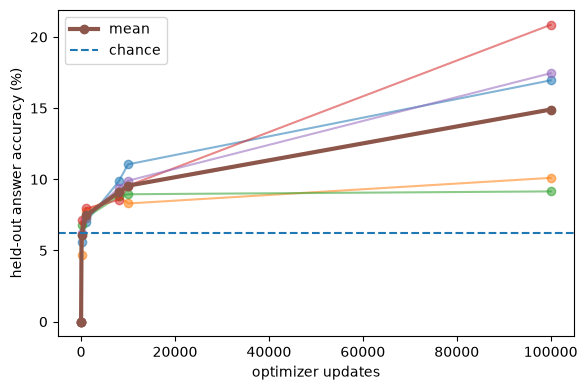

In [8]:

fig=plt.figure(figsize=(6,4))
for seed in SEEDS:
    r=[x for x in rows if x["seed"]==seed]
    plt.plot([x["step"] for x in r],[100*x["accuracy"] for x in r],marker="o",alpha=.55)
steps=sorted({r["step"] for r in rows})
means=[100*np.mean([r["accuracy"] for r in rows if r["step"]==s]) for s in steps]
plt.plot(steps,means,marker="o",linewidth=3,label="mean")
plt.axhline(100*task.chance_acc,linestyle="--",label="chance")
plt.xlabel("optimizer updates"); plt.ylabel("held-out answer accuracy (%)"); plt.legend()
plt.tight_layout(); plt.savefig(OUT/f"outcome_long_{TASK}.pdf",bbox_inches="tight"); plt.show()



# 6.3 — Transformer residuals vs. conditional-credit proxy

This section uses the **actual repository `GPTModel` and compiled training path**.

Training/data infrastructure is imported from `src.utils` and `compare_supervision`; only the diagnostic computations are custom, because the paper's proposed forward/backward quantities are neural proxies rather than quantities exposed directly by the current training code.

The model is trained through the compiled wrapper returned by `src.utils.build_model`. Diagnostics are then evaluated on `base_model`, which is the same trained `GPTModel` object whose parameters underlie the compiled wrapper.

Interpretation remains deliberately limited: these quantities are a bridge from the exact matrix theorem to the two-block pre-LN Transformer, not an assertion that the Transformer literally implements \(q_t,\beta_t,\Pi_{\mathcal C}\).


In [ ]:

# 6.3 — repository-native Transformer setup.
# We train with src.utils.build_model/build_optimizer/build_train_loader and
# torch.compile on CUDA, then diagnose the underlying base_model.

import csv
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from src.registry import TASKS
from src.utils import (
    build_model as build_repo_model,
    build_optimizer as build_repo_optimizer,
    build_train_loader as build_repo_train_loader,
    set_seed as repo_set_seed,
    cleanup as repo_cleanup,
)
from compare_supervision import SupervisionDataset, generate_unique
# from mechanism_diagnostics import build_teacher_queries

DEVICE_STR = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = torch.device(DEVICE_STR)
USE_COMPILE = DEVICE_STR == "cuda"
USE_BF16 = DEVICE_STR == "cuda" and torch.cuda.is_bf16_supported()

FULL = True
DEPTHS = [4, 8, 12] if FULL else [4]
SEEDS = [2001, 2002, 2003, 2004, 2005] if FULL else [2001]
STEPS = 8_000 if FULL else 50
NPROBE = 128 if FULL else 16
TRAIN_SIZE = 100_000 if FULL else 2_000
VAL_SIZE = 2_000 if FULL else 128


DIAG_SEED = 20260905
CALIB_SIZE = 1024
EVAL_SIZE = 512
BATCH = 128
BATCH_SEED = 12345
TRAIN_SEED = 501
VAL_SEED = 101
NUM_WORKERS = 4

N_EMBD = 128
N_HEAD = 4
N_LAYER = 2
DROPOUT = 0.0
LR = 3e-4
WEIGHT_DECAY = 0.0
GRAD_CLIP = 1.0


STATE_CLASSES = 16
PROBE_STEPS = 300
PROBE_LR = 5e-2
PROBE_WD = 1e-4


OUT = Path("results/section6_all")
OUT.mkdir(parents=True, exist_ok=True)

print("device:", DEVICE_STR, "| torch.compile:", USE_COMPILE, "| FULL:", FULL)


device: cuda | torch.compile: True | FULL: True


In [23]:
# ============================================================
# 6.3 DIAGNOSTIC ON THE ACTUAL OUTCOME-ONLY TRAJECTORY
# ============================================================

import math


def gate_end_token_positions(task, prompt):
    """
    Token positions of the final character of gate 1,...,D in the actual prompt.

    boolean prompt:
        i0101;ux0c12s01t012...
    No intermediate state/trace tokens are inserted.
    """
    marker = ";u"
    start = prompt.index(marker) + len(marker)
    ops = prompt[start:]

    gate_len = {"x": 2, "c": 3, "s": 3, "t": 4}

    positions = []
    i = 0

    while i < len(ops):
        op = ops[i]

        if op not in gate_len:
            raise ValueError(f"Could not parse gate string at: {ops[i:]}")

        L = gate_len[op]
        char_end = start + i + L - 1

        # Robustly convert character boundary to tokenizer position.
        token_end = len(task.tokenizer.encode(prompt[:char_end + 1])) - 1

        positions.append(token_end)
        i += L

    return positions


def true_state_labels(inst):
    """
    Diagnostic labels only.
    IMPORTANT: these states are NEVER supplied to the Transformer input.
    """
    return [
        int(step.rsplit(">", 1)[1], 2)
        for step in inst.correct_trace.split()
    ]


def build_outcome_batch(task, insts):
    """
    Build exactly the OUTCOME-ONLY sequence:

        prompt + " : gold\\n"

    The loss mask below selects only the four terminal answer bits for the
    mechanistic diagnostic. No clean trace appears anywhere in x.
    """
    rows = []

    for inst in insts:
        prompt_ids = task.tokenizer.encode(inst.prompt)
        target_ids = task.tokenizer.encode(f" : {inst.gold}\n")
        full_ids = prompt_ids + target_ids

        gate_pos = gate_end_token_positions(task, inst.prompt)
        states = true_state_labels(inst)

        if len(gate_pos) != len(states):
            raise RuntimeError(
                f"gate/state mismatch: {len(gate_pos)} vs {len(states)}"
            )

        rows.append(
            (full_ids, len(prompt_ids), gate_pos, states, len(inst.gold))
        )

    T = max(len(ids) - 1 for ids, *_ in rows)
    B = len(rows)
    pad = task.tokenizer.pad_id

    x = torch.full((B, T), pad, dtype=torch.long, device=DEVICE)
    y = torch.full((B, T), pad, dtype=torch.long, device=DEVICE)
    answer_mask = torch.zeros(B, T, dtype=torch.float32, device=DEVICE)

    gate_positions = []
    state_labels = []

    prefix_len = len(task.tokenizer.encode(" : "))

    for i, (ids, prompt_len, gpos, states, gold_len) in enumerate(rows):
        z = torch.tensor(ids, dtype=torch.long, device=DEVICE)
        n = len(ids) - 1

        x[i, :n] = z[:-1]
        y[i, :n] = z[1:]

        # To predict token at absolute index j, use logits at j-1.
        gold_start = prompt_len + prefix_len
        answer_mask[
            i,
            gold_start - 1 : gold_start - 1 + gold_len
        ] = 1.0

        gate_positions.append(gpos)
        state_labels.append(states)

    D = len(gate_positions[0])

    if any(len(p) != D for p in gate_positions):
        raise RuntimeError("Mixed circuit depths inside one diagnostic batch.")

    gate_positions = torch.tensor(
        gate_positions, dtype=torch.long, device=DEVICE
    )
    state_labels = torch.tensor(
        state_labels, dtype=torch.long, device=DEVICE
    )

    return x, y, answer_mask, gate_positions, state_labels


def forward_with_h1(model, x):
    """
    Explicit repository GPTModel forward so that we can inspect h1.

    h1 = output of Transformer block 1.

    This is the appropriate bridge representation because the second block's
    answer position can causally attend to block-1 representations of earlier
    prompt/gate positions.
    """
    B, T = x.shape

    pos = torch.arange(T, device=x.device)

    h = (
        model.token_embedding_table(x)
        + model.position_embedding_table(pos)
    )

    h1 = model.blocks[0](h)

    h = h1
    for block in list(model.blocks)[1:]:
        h = block(h)

    logits = model.lm_head(model.ln_f(h))

    return h1, logits


def terminal_answer_loss(model, task, insts, return_h1=False):
    """
    Loss only on the four terminal answer bits.

    This avoids delimiter/newline syntax dominating the mechanistic signal.
    """
    x, y, mask, gate_pos, state_labels = build_outcome_batch(task, insts)

    h1, logits = forward_with_h1(model, x)

    token_loss = F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        y.reshape(-1),
        reduction="none",
        ignore_index=task.tokenizer.pad_id,
    ).view_as(y)

    loss = (
        (token_loss * mask).sum()
        / mask.sum().clamp_min(1.0)
    )

    if return_h1:
        return loss, h1, gate_pos, state_labels

    return loss


@torch.no_grad()
def collect_h1_features(model, task, insts):
    """
    Actual prompt representations at each gate boundary.
    """
    model.eval()

    _, h1, gate_pos, labels = terminal_answer_loss(
        model,
        task,
        insts,
        return_h1=True,
    )

    B, D = gate_pos.shape
    batch = torch.arange(B, device=DEVICE)[:, None]

    features = h1[batch, gate_pos]

    return features.detach(), labels.detach()


def fit_position_state_probe(model, task, calib):
    """
    Fit D independent linear state probes using a calibration split.

    The Transformer is frozen. Only the diagnostic heads are optimized.
    Evaluation is performed on a disjoint held-out split.
    """
    feats, labels = collect_h1_features(model, task, calib)

    feats = feats.float()

    _, D, H = feats.shape

    mu = feats.mean(dim=0, keepdim=True)
    sd = feats.std(dim=0, keepdim=True).clamp_min(1e-4)

    z = (feats - mu) / sd

    # Deterministic zero initialization; no seed-searching.
    W = torch.zeros(
        D,
        STATE_CLASSES,
        H,
        device=DEVICE,
        requires_grad=True,
    )

    b = torch.zeros(
        D,
        STATE_CLASSES,
        device=DEVICE,
        requires_grad=True,
    )

    optimizer = torch.optim.AdamW(
        [W, b],
        lr=PROBE_LR,
        weight_decay=PROBE_WD,
    )

    for _ in range(PROBE_STEPS):
        logits = torch.einsum(
            "ndh,dch->ndc",
            z,
            W,
        ) + b[None]

        loss = F.cross_entropy(
            logits.reshape(-1, STATE_CLASSES),
            labels.reshape(-1),
        )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    return {
        "W": W.detach(),
        "b": b.detach(),
        "mu": mu.detach(),
        "sd": sd.detach(),
    }


def probe_logits(features, probe):
    z = (
        features.float() - probe["mu"]
    ) / probe["sd"]

    return (
        torch.einsum(
            "ndh,dch->ndc",
            z,
            probe["W"],
        )
        + probe["b"][None]
    )


def gradvec_allow_unused(model, loss):
    """
    Some local-state losses only use parameters upstream of block 1.
    Later-block gradients are therefore legitimately zero.
    """
    params = [
        p for p in model.parameters()
        if p.requires_grad
    ]

    grads = torch.autograd.grad(
        loss,
        params,
        retain_graph=False,
        allow_unused=True,
    )

    flat = []

    for p, g in zip(params, grads):
        if g is None:
            g = torch.zeros_like(p)

        flat.append(g.reshape(-1))

    return torch.cat(flat)


def diagnose_actual_outcome_trajectory(model, task, calib, eval_insts):
    """
    Three neural proxies evaluated at the SAME actual gate positions.

    Forward:
        held-out intermediate-state information in h1.

    Backward:
        sensitivity of terminal-answer loss to h1 at that gate.

    Conditional credit:
        projection of the outcome gradient onto the gradient direction
        induced by a frozen local-state decoder.

    No correct trace is inserted into the model input.
    """
    model.eval()

    decoder = fit_position_state_probe(
        model,
        task,
        calib,
    )

    # --------------------------------------------------------
    # FORWARD PROXY
    # held-out improvement over uniform 16-state log loss
    # --------------------------------------------------------

    with torch.no_grad():
        feats_eval, labels_eval = collect_h1_features(
            model,
            task,
            eval_insts,
        )

        lp = probe_logits(
            feats_eval,
            decoder,
        )

        D = lp.shape[1]

        forward = []
        probe_acc = []

        for t in range(D):
            ce = F.cross_entropy(
                lp[:, t],
                labels_eval[:, t],
            ).item()

            # Uniform-state CE is log(16).
            # Positive value means held-out state information is recoverable.
            info = max(
                0.0,
                math.log(STATE_CLASSES) - ce,
            )

            forward.append(info)

            acc = (
                lp[:, t].argmax(dim=-1)
                == labels_eval[:, t]
            ).float().mean().item()

            probe_acc.append(acc)

    # --------------------------------------------------------
    # BACKWARD PROXY
    # answer-loss sensitivity to the SAME h1 gate positions
    # --------------------------------------------------------

    answer_loss, h1, gate_pos, _ = terminal_answer_loss(
        model,
        task,
        eval_insts,
        return_h1=True,
    )

    dh1, = torch.autograd.grad(
        answer_loss,
        h1,
        retain_graph=False,
    )

    B, D = gate_pos.shape
    batch = torch.arange(B, device=DEVICE)[:, None]

    backward = (
        dh1[batch, gate_pos]
        .norm(dim=-1)
        .mean(dim=0)
        .detach()
        .cpu()
        .numpy()
    )

    # --------------------------------------------------------
    # TERMINAL OUTCOME GRADIENT
    # --------------------------------------------------------

    gout = gradvec_allow_unused(
        model,
        terminal_answer_loss(
            model,
            task,
            eval_insts,
        ),
    ).detach()

    # --------------------------------------------------------
    # CONDITIONAL-CREDIT PROXY
    #
    # Frozen state probe defines a local state-learning direction.
    # We measure how much outcome gradient lies along that direction.
    # --------------------------------------------------------

    credit = []

    for t in range(D):

        _, h1_t, gate_pos_t, labels_t = terminal_answer_loss(
            model,
            task,
            eval_insts,
            return_h1=True,
        )

        batch_t = torch.arange(
            len(eval_insts),
            device=DEVICE,
        )

        ht = h1_t[
            batch_t,
            gate_pos_t[:, t],
        ]

        zt = (
            ht.float() - decoder["mu"][0, t]
        ) / decoder["sd"][0, t]

        local_logits = (
            zt @ decoder["W"][t].T
            + decoder["b"][t]
        )

        local_loss = F.cross_entropy(
            local_logits,
            labels_t[:, t],
        )

        glocal = gradvec_allow_unused(
            model,
            local_loss,
        ).detach()

        projection = torch.dot(
            gout,
            glocal,
        ) / (
            glocal.norm() + 1e-12
        )

        credit.append(
            float(projection)
        )

    forward = np.asarray(
        forward,
        dtype=float,
    )

    backward = np.asarray(
        backward,
        dtype=float,
    )

    credit = np.asarray(
        credit,
        dtype=float,
    )

    probe_acc = np.asarray(
        probe_acc,
        dtype=float,
    )

    product = forward * backward

    if (
        np.std(product) > 0
        and np.std(np.abs(credit)) > 0
    ):
        corr = np.corrcoef(
            product,
            np.abs(credit),
        )[0, 1]
    else:
        corr = np.nan

    return (
        forward,
        backward,
        credit,
        product,
        probe_acc,
        corr,
    )

trained with repo compiled path and saved: results/section6_all/outcome_long_boolean_circuit_4_seed3001_step8000.pt
D=4 seed=3001 within-run-r=-0.387 state-probe=29.59%
trained with repo compiled path and saved: results/section6_all/outcome_long_boolean_circuit_4_seed3002_step8000.pt
D=4 seed=3002 within-run-r=+0.720 state-probe=27.88%
trained with repo compiled path and saved: results/section6_all/outcome_long_boolean_circuit_4_seed3003_step8000.pt
D=4 seed=3003 within-run-r=+0.969 state-probe=32.42%
trained with repo compiled path and saved: results/section6_all/outcome_long_boolean_circuit_4_seed3004_step8000.pt
D=4 seed=3004 within-run-r=-0.002 state-probe=28.76%
trained with repo compiled path and saved: results/section6_all/outcome_long_boolean_circuit_4_seed3005_step8000.pt
D=4 seed=3005 within-run-r=+0.513 state-probe=24.02%
trained with repo compiled path and saved: results/section6_all/outcome_long_boolean_circuit_8_seed3001_step8000.pt
D=8 seed=3001 within-run-r=-0.373 state

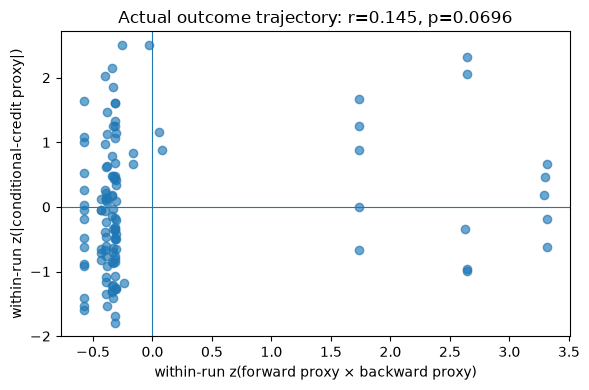

In [24]:

def train_or_load_repo_outcome(task, train_instances, seed, steps):
    ckpt = OUT / f"outcome_long_{task.name}_seed{seed}_step{steps}.pt"

    repo_set_seed(seed)
    base_model, model = build_repo_model(
        vocab_size=task.tokenizer.vocab_size,
        block_size=task.block_size,
        pad_id=task.tokenizer.pad_id,
        n_embd=N_EMBD,
        n_head=N_HEAD,
        n_layer=N_LAYER,
        dropout=DROPOUT,
        device=DEVICE_STR,
        use_compile=USE_COMPILE,
    )

    if ckpt.exists():
        base_model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        print("loaded:", ckpt)
        return base_model, model

    dataset = SupervisionDataset(train_instances, task, "outcome")
    loader, loader_generator = build_repo_train_loader(
        train_dataset=dataset,
        batch_size=BATCH,
        batch_seed=BATCH_SEED,
        num_workers=NUM_WORKERS,
        device=DEVICE_STR,
    )
    iterator = iter(loader)

    optimizer = build_repo_optimizer(
        model=model,
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        device=DEVICE_STR,
    )

    for step in range(steps):
        try:
            x, y, mask = next(iterator)
        except StopIteration:
            iterator = iter(loader)
            x, y, mask = next(iterator)

        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        mask = mask.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if USE_BF16:
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                _, loss = model(x, targets=y, mask=mask)
        else:
            _, loss = model(x, targets=y, mask=mask)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

    torch.save(base_model.state_dict(), ckpt)
    print("trained with repo compiled path and saved:", ckpt)

    del optimizer, iterator, loader, loader_generator, dataset
    repo_cleanup()
    return base_model, model

# ============================================================
# RUN CONFIRMATORY 6.3
# ============================================================

rows = []
run_results = []

for D in DEPTHS:

    task = TASKS[f"boolean_circuit_{D}"]

    # Same training distribution/pool construction as before.
    train_instances = generate_unique(
        task,
        TRAIN_SIZE,
        TRAIN_SEED,
    )

    train_prompts = {
        inst.prompt
        for inst in train_instances
    }

    # New fixed diagnostic population, completely excluded from training.
    diag_instances = generate_unique(
        task,
        CALIB_SIZE + EVAL_SIZE,
        DIAG_SEED,
        train_prompts,
    )

    calib = diag_instances[:CALIB_SIZE]

    eval_insts = diag_instances[
        CALIB_SIZE:
        CALIB_SIZE + EVAL_SIZE
    ]

    # Explicit sanity checks.
    assert not (
        {z.prompt for z in calib}
        & train_prompts
    )

    assert not (
        {z.prompt for z in eval_insts}
        & train_prompts
    )

    assert not (
        {z.prompt for z in calib}
        & {z.prompt for z in eval_insts}
    )

    for seed in SEEDS:

        base_model, compiled_model = (
            train_or_load_repo_outcome(
                task,
                train_instances,
                seed,
                STEPS,
            )
        )

        (
            forward,
            backward,
            credit,
            product,
            probe_acc,
            corr,
        ) = diagnose_actual_outcome_trajectory(
            base_model,
            task,
            calib,
            eval_insts,
        )

        print(
            f"D={D} seed={seed} "
            f"within-run-r={corr:+.3f} "
            f"state-probe={100*probe_acc.mean():.2f}%"
        )

        run_results.append({
            "depth": D,
            "seed": seed,
            "corr": float(corr),
        })

        for t in range(D):
            rows.append({
                "depth": D,
                "seed": seed,
                "t": t + 1,
                "forward": float(forward[t]),
                "backward": float(backward[t]),
                "product": float(product[t]),
                "credit": float(credit[t]),
                "abs_credit": float(abs(credit[t])),
                "probe_acc": float(probe_acc[t]),
            })

        del compiled_model, base_model
        repo_cleanup()


# ============================================================
# SAVE
# ============================================================

with open(
    OUT / "transformer_residual_credit_actual_trajectory.csv",
    "w",
    newline="",
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=rows[0].keys(),
    )

    writer.writeheader()
    writer.writerows(rows)


# ============================================================
# PRIMARY ANALYSIS:
# WITHIN-RUN ASSOCIATION
#
# DO NOT use the raw pooled correlation as the primary statistic.
# Standardize within each (depth, seed), then pool.
# ============================================================

def zscore(x):
    x = np.asarray(x, dtype=float)
    sd = x.std(ddof=0)

    if sd <= 0:
        return np.zeros_like(x)

    return (
        x - x.mean()
    ) / sd


groups = []

for D in DEPTHS:
    for seed in SEEDS:

        group = [
            r for r in rows
            if r["depth"] == D
            and r["seed"] == seed
        ]

        xg = np.array(
            [r["product"] for r in group],
            dtype=float,
        )

        yg = np.array(
            [r["abs_credit"] for r in group],
            dtype=float,
        )

        if (
            len(xg) > 1
            and np.std(xg) > 0
            and np.std(yg) > 0
        ):
            groups.append(
                (
                    D,
                    seed,
                    zscore(xg),
                    zscore(yg),
                )
            )


zx = np.concatenate([
    g[2]
    for g in groups
])

zy = np.concatenate([
    g[3]
    for g in groups
])

within_corr = np.corrcoef(
    zx,
    zy,
)[0, 1]


# ============================================================
# PER-RUN CORRELATIONS
# ============================================================

run_corrs = np.array([
    r["corr"]
    for r in run_results
    if np.isfinite(r["corr"])
])

print()
print("PRIMARY RESULTS")
print("-------------------------------")
print(
    f"within-run standardized r = "
    f"{within_corr:+.4f}"
)
print(
    f"mean per-run r            = "
    f"{run_corrs.mean():+.4f}"
)
print(
    f"median per-run r          = "
    f"{np.median(run_corrs):+.4f}"
)


# ============================================================
# DEPTH-SPECIFIC WITHIN-RUN CORRELATIONS
# ============================================================

for D in DEPTHS:

    dg = [
        g for g in groups
        if g[0] == D
    ]

    dx = np.concatenate([
        g[2]
        for g in dg
    ])

    dy = np.concatenate([
        g[3]
        for g in dg
    ])

    rD = np.corrcoef(
        dx,
        dy,
    )[0, 1]

    print(
        f"D={D:2d} within-run standardized r = "
        f"{rD:+.4f}"
    )


# ============================================================
# GROUP-PRESERVING PERMUTATION TEST
#
# Shuffle |credit| across positions only WITHIN each model run.
# This preserves all between-seed and between-depth scale effects.
# ============================================================

rng = np.random.default_rng(123456)

N_PERM = 10_000
null = np.empty(N_PERM)

for b in range(N_PERM):

    px = []
    py = []

    for _, _, xg, yg in groups:
        px.append(xg)
        py.append(rng.permutation(yg))

    px = np.concatenate(px)
    py = np.concatenate(py)

    null[b] = np.corrcoef(
        px,
        py,
    )[0, 1]


p_value = (
    1
    + np.sum(null >= within_corr)
) / (
    N_PERM + 1
)

print(
    f"group-preserving one-sided permutation p = "
    f"{p_value:.5f}"
)


plt.figure(figsize=(6, 4))

plt.scatter(
    zx,
    zy,
    alpha=0.65,
)

plt.axhline(
    0,
    linewidth=0.8,
)

plt.axvline(
    0,
    linewidth=0.8,
)

plt.xlabel(
    "within-run z(forward proxy × backward proxy)"
)

plt.ylabel(
    "within-run z(|conditional-credit proxy|)"
)

plt.title(
    f"Actual outcome trajectory: "
    f"r={within_corr:.3f}, p={p_value:.4f}"
)

plt.tight_layout()

plt.savefig(
    OUT / "transformer_residual_credit_actual_trajectory.pdf",
    bbox_inches="tight",
)

plt.show()




# 6.4 — Exact-population Hessian signature at marginal collapse

Compact theorem-matched test of Theorem 6 using the **full $K=16$, $M=52$** reversible Boolean operator family.

The model is exactly the one-block/no-LayerNorm architecture required by the theorem. At marginal collapse:
$W_E=W_U=W_O=W_2=0$, $b=\log\pi$.

Two exact populations are used:

- **outcome-like:** current state token and terminal target are independent uniform $\Rightarrow C=0$;
- **process:** source state is mapped to its one-step successor under all 52 reversible gates $\Rightarrow C\neq0$.

Lanczos uses Hessian-vector products; no dense Hessian is formed.


For the zero-covariance branch, interpret a numerically PSD Hessian as **no detectable negative curvature**, not as numerical proof of a local minimum.

In [1]:

import math, numpy as np, torch
import torch.nn as nn
import torch.nn.functional as F

torch.set_default_dtype(torch.float64)
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
K=16; D=32

def bits(x): return [int(c) for c in f"{x:04b}"]
def val(b): return int("".join(map(str,b)),2)
def apply(s,g):
    r=bits(s)
    if g[0]=="x": r[int(g[1])]^=1
    elif g[0]=="c": i,j=map(int,g[1:]); r[j]^=r[i]
    elif g[0]=="s": i,j=map(int,g[1:]); r[i],r[j]=r[j],r[i]
    else: i,j,k=map(int,g[1:]); r[k]^=r[i]&r[j]
    return val(r)

G=([f"x{i}" for i in range(4)]+[f"c{i}{j}" for i in range(4) for j in range(4) if i!=j]+
   [f"s{i}{j}" for i in range(4) for j in range(4) if i!=j]+
   [f"t{i}{j}{k}" for i in range(4) for j in range(4) for k in range(4) if len({i,j,k})==3])
mult={"x":6,"c":2,"s":2,"t":1}   # exact family-uniform weighting denominator 96

xo=[]; yo=[]
for x in range(K):
    for y in range(K): xo.append(x); yo.append(y)

xp=[]; yp=[]
for x in range(K):
    for g in G:
        for _ in range(mult[g[0]]): xp.append(x); yp.append(apply(x,g))

xo,yo,xp,yp=[torch.tensor(z,device=DEVICE) for z in (xo,yo,xp,yp)]
print(len(G),len(xo),len(xp))


52 256 1536


In [2]:

class OneBlock(nn.Module):
    def __init__(self):
        super().__init__(); self.E=nn.Embedding(K,D); self.pos=nn.Parameter(torch.randn(1,D)*.1)
        self.q=nn.Linear(D,D,bias=False); self.k=nn.Linear(D,D,bias=False); self.v=nn.Linear(D,D,bias=False); self.o=nn.Linear(D,D,bias=False)
        self.w1=nn.Linear(D,2*D); self.w2=nn.Linear(2*D,D); self.head=nn.Linear(D,K)
    def forward(self,x):
        z=self.E(x)+self.pos; q,k,v=self.q(z),self.k(z),self.v(z); a=(q@k.transpose(-1,-2)/math.sqrt(D)).softmax(-1)
        z=z+self.o(a@v); z=z+self.w2(F.relu(self.w1(z))); return self.head(z)

@torch.no_grad()
def collapse(m):
    m.E.weight.zero_(); m.o.weight.zero_(); m.w2.weight.zero_(); m.w2.bias.zero_(); m.head.weight.zero_(); m.head.bias.fill_(math.log(1/K))

def cov(x,y):
    X=F.one_hot(x,K).double(); Y=F.one_hot(y,K).double()
    return Y.T@X/len(x)-Y.mean(0)[:,None]@X.mean(0)[None,:]

print("||C_out|| =",cov(xo,yo).norm().item(),"||C_proc|| =",cov(xp,yp).norm().item())


||C_out|| = 0.0 ||C_proc|| = 0.11285389937510652


In [3]:

def closure(m,x,y): return lambda: F.cross_entropy(m(x[:,None])[:,0],y)
def ps(m): return [p for p in m.parameters() if p.requires_grad]
def flat(z): return torch.cat([x.reshape(-1) for x in z])
def split(v,P):
    z=[]; i=0
    for p in P: z.append(v[i:i+p.numel()].view_as(p)); i+=p.numel()
    return z

def hvp(m,L,v):
    P=ps(m); g=torch.autograd.grad(L(),P,create_graph=True,allow_unused=True); g=[torch.zeros_like(p) if x is None else x for p,x in zip(P,g)]
    s=sum((a*b).sum() for a,b in zip(g,split(v,P))); H=torch.autograd.grad(s,P,allow_unused=True)
    return flat([torch.zeros_like(p) if x is None else x for p,x in zip(P,H)]).detach()

def lanczos(m,L,n=25,seed=1):
    N=sum(p.numel() for p in ps(m)); q=torch.randn(N,device=DEVICE,generator=torch.Generator(device=DEVICE).manual_seed(seed)); q/=q.norm()
    Q=[]; A=[]; B=[]; prev=torch.zeros_like(q); beta=0.
    for j in range(n):
        Q.append(q); z=hvp(m,L,q)-(beta*prev if j else 0); a=q@z; z-=a*q
        for qi in Q: z-= (qi@z)*qi
        b=z.norm(); A.append(a); 
        if j<n-1: B.append(b)
        if b<1e-12: break
        prev,q,beta=q,z/b,b
    m0=len(A); T=torch.zeros(m0,m0,device=DEVICE)
    for i in range(m0):
        T[i,i]=A[i]
        if i+1<m0: T[i,i+1]=T[i+1,i]=B[i]
    e,V=torch.linalg.eigh(T); Qm=torch.stack(Q[:m0],1); return float(e[0]),float(e[-1]),Qm@V[:,0]

def gradnorm(m,L):
    g=torch.autograd.grad(L(),ps(m),allow_unused=True); return flat([torch.zeros_like(p) if x is None else x for p,x in zip(ps(m),g)]).norm().item()


In [4]:

torch.manual_seed(3); m=OneBlock().to(DEVICE); collapse(m)
Lo,Lp=closure(m,xo,yo),closure(m,xp,yp)
go,gp=gradnorm(m,Lo),gradnorm(m,Lp)
omin,omax,vo=lanczos(m,Lo); pmin,pmax,vp=lanczos(m,Lp)

def loading(v):
    out={}; i=0
    for name,p in m.named_parameters():
        z=float(v[i:i+p.numel()].pow(2).sum()); i+=p.numel()
        k="WE" if name.startswith("E.") else "WU" if name.startswith("head.") else "other"; out[k]=out.get(k,0)+z
    s=sum(out.values()); return {k:v/s for k,v in out.items()}

print(f"outcome: grad={go:.3e} lambda_min={omin:.6g} lambda_max={omax:.6g}")
print(f"process: grad={gp:.3e} lambda_min={pmin:.6g} lambda_max={pmax:.6g}")
print("process v_min loading:",loading(vp))

assert go<1e-8 and gp<1e-8
assert omin>-1e-7 and pmin<0


outcome: grad=2.277e-17 lambda_min=-1.85598e-20 lambda_max=0.0857438
process: grad=1.460e-15 lambda_min=-0.0512381 lambda_max=0.0952178
process v_min loading: {'other': 1.6478244957875943e-16, 'WE': 0.5000000000003787, 'WU': 0.49999999999962114}


## Interpretation checklist

- **6.1:** the key falsification is a depth-independent fitted exponent. Report censoring and the measured Assumption-1 diagnostics. Do not force a slope from selectively uncensored runs.
- **6.2:** eventual long-horizon escape is not fatal; the theorem predicts delayed escape, not permanent failure. Early, depth-insensitive escape is more problematic.
- **6.3:** a strong residual-product/credit correlation closes the matrix-to-Transformer bridge. A weak result does not invalidate the exact matrix theorem, but the paper should then avoid quantitative transfer claims.
- **6.4:** report gradient norm, extremal Hessian eigenvalues, and the process negative-eigenvector loading on `WE/WU`. Do not say that the numerical PSD branch proves a local minimum.